Loaded 17,288 rows
         datetime_utc region  demand_mwh  hour  day_of_week  month  is_weekend
0 2026-03-15 22:00:00   BPAT        7608    22            6      3           1
1 2026-03-15 23:00:00   BPAT        7638    23            6      3           1
2 2026-03-16 00:00:00   BPAT        7784     0            0      3           0
3 2026-03-16 01:00:00   BPAT        7957     1            0      3           0
4 2026-03-16 02:00:00   BPAT        8097     2            0      3           0


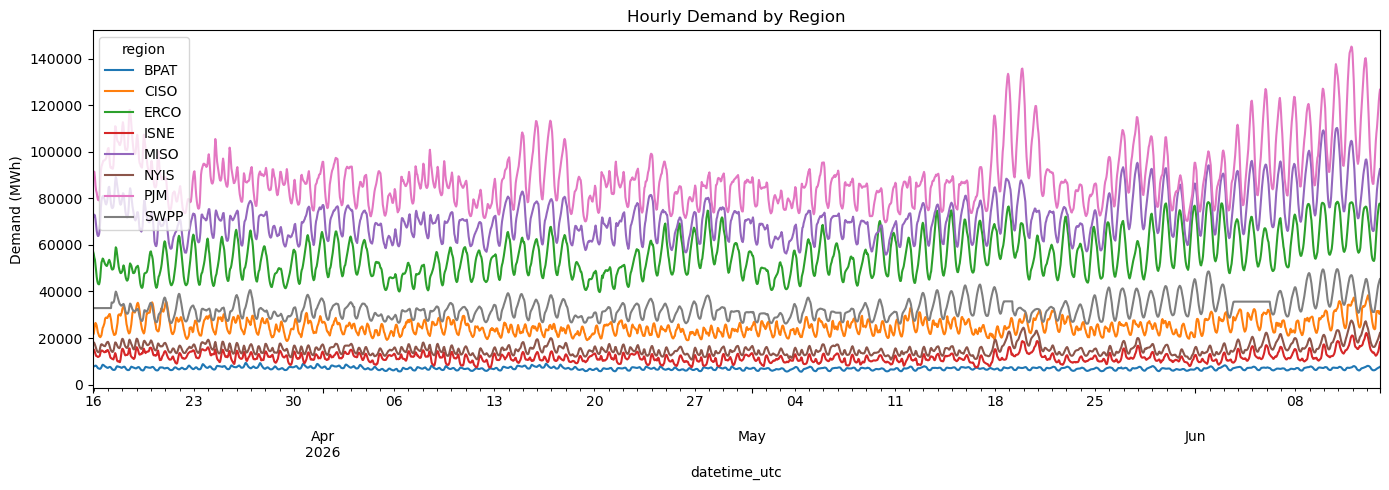

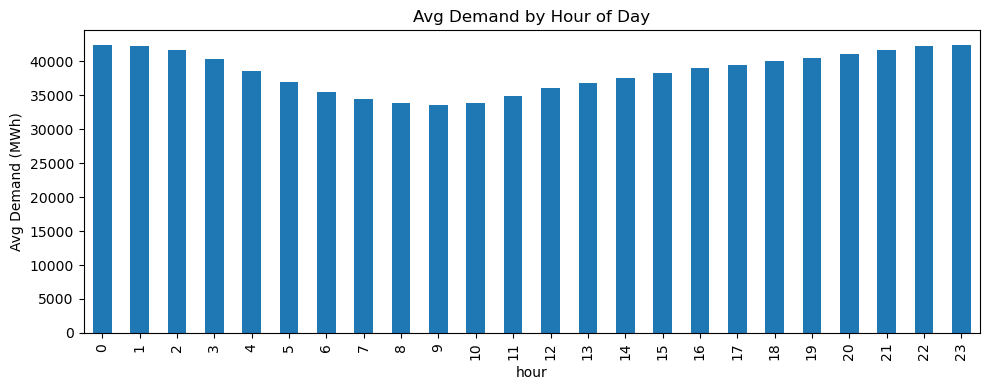

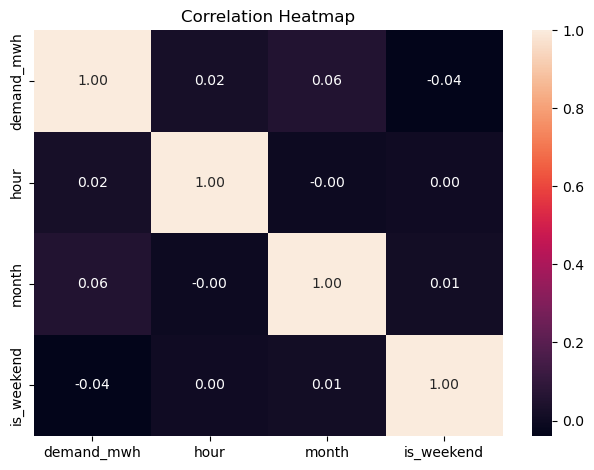

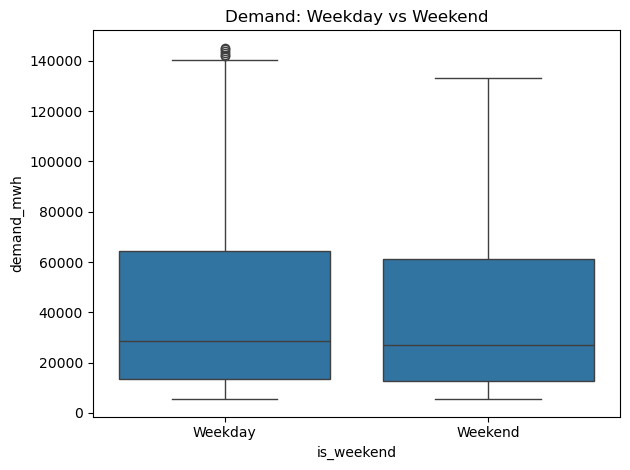

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Update this if your repo is cloned to a different location
root = Path.home() / "Documents" / "AI4ALL-Group-11A"

df = pd.read_csv(root / "data" / "raw" / "eia_energy_data.csv", parse_dates=["datetime_utc"])
print(f"Loaded {len(df):,} rows")
print(df.head())

# Demand over time per region
df.pivot(index="datetime_utc", columns="region", values="demand_mwh").plot(figsize=(14, 5), title="Hourly Demand by Region")
plt.ylabel("Demand (MWh)")
plt.tight_layout()
plt.show()

# Average demand by hour of day
df.groupby("hour")["demand_mwh"].mean().plot(kind="bar", title="Avg Demand by Hour of Day", figsize=(10, 4))
plt.ylabel("Avg Demand (MWh)")
plt.tight_layout()
plt.show()

# Correlation heatmap (only columns present in data)
num_cols = [c for c in ["demand_mwh", "solar_gen_mwh", "wind_gen_mwh", "hour", "month", "is_weekend"] if c in df.columns]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Weekend vs weekday demand distribution
sns.boxplot(x="is_weekend", y="demand_mwh", data=df)
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.title("Demand: Weekday vs Weekend")
plt.tight_layout()
plt.show()